# Notebook to preprocess IFRC reports

## Steps
1. Load reports text from JSON (check it is the correct version, eventually redo scraping ourself)
2. Filter out unnessecary reports
3. Clean text
4. Separate sentences and tokenize
5. Add hazard category for each report (use Laura's reclassifying)
6. Add division according to header


In [1]:
import pandas as pd
import json
from collections import Counter
from text_processing_functions import *
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import copy as cp
import spacy
import re

In [2]:
DATA_FOLDER = '../Data_backup'

In [3]:
file_path = DATA_FOLDER + '/all_ifrc_reports_info_unnested.json' #not sure if this is the correct file

# Open and read the JSON file
with open(file_path, 'r') as json_file:
    all_ifrc_reports_info_unnested = json.load(json_file)

In [4]:
# Convert the JSON data into a Pandas DataFrame
data = pd.DataFrame(all_ifrc_reports_info_unnested)

In [5]:
data

,reportName,disasterType,date,reportLink,location,appealCode,appealType,pdfDownloaded,text,disasterTypeFlag,disasterTypeReclassified
0,Uzbekistan 2024 Unified Plan (UPL-2024-MAAUZ002),Unified Plan,09/07/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Uzbekistan,UPL-2024-MAAUZ002,IFRC Network Plan,1,﻿\nUZBEKISTAN\n2024 IFRC network country plan\...,1.0,Unified Plan
1,Pakistan - Monsoon Floods (MDRPK006),Flood,08/07/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Pakistan,MDRPK006,Operations Update,1,\n \n \n \n \n \nRes\ntric\nted \n \n \n \n \...,NaN,Flood
2,El Salvador - Floods (MDRSV016),Flood,04/07/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,El Salvador,MDRSV016,DREF Operation,1,DREF Operation\nEl Salvador: Floods\nNational ...,NaN,Flood
3,South Africa - Thunderstorm and Floods (MDRZA018),Flood,02/07/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,South Africa,MDRZA018,DREF Operation,1,DREF Operation\nSouth Africa_Thunderstorms and...,NaN,Flood
4,Bangladesh - Cyclone (MDRBD035),Cyclone,02/07/2024,https://adore.ifrc.org/Download.aspx?FileId=83...,Bangladesh,MDRBD035,Operations Update,1,1 \nEMERGENCY APPEAL \nBangladesh | Cyclone Re...,NaN,Cyclone
...,...,...,...,...,...,...,...,...,...,...,...
3619,Outbreak of cerebro-spinal meningitis,Other,29/02/1996,https://go-api.ifrc.org/publicfile/download?pa...,Nigeria,496,Information Bulletin,1,NIGERIA: OUTBREAK OF CEREBRO\nSPINAL MENINGITI...,1.0,Other
3620,Earthquake in Irian Jaya,Earthquake,21/02/1996,https://go-api.ifrc.org/publicfile/download?pa...,Indonesia,0,Information Bulletin,1,NO. 1\n5 February 1996\nCHINA : E...,1.0,Earthquake
3621,Earthquake in Yunnan province,Earthquake,14/02/1996,https://go-api.ifrc.org/publicfile/download?pa...,China,0,Information Bulletin,1,NO. 1\n5 February 1996\nCHINA : E...,NaN,Earthquake
3622,Earthquake in Yunnan province,Earthquake,13/02/1996,https://go-api.ifrc.org/publicfile/download?pa...,China,0,Information Bulletin,1,NO. 1\n5 February 1996\nCHINA : E...,NaN,Earthquake


## Filtering useless reports

In [6]:
## filter out useless reports
filtered_reports = [
    disaster_report for disaster_report in all_ifrc_reports_info_unnested
    if disaster_report['appealType'] in ['Operations Update', 'DREF Operation', 'DREF Operation Final Report', 'DREF Operation Update']
]

## Text preprocessing

In [7]:
#load libraries fo nlp
#not clear exactly which preprocessing steps must be undertaken
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt_tab')
nltk.download('punkt')  # Download sentence tokenizer
nltk.download('stopwords') # Download stopwords

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
#clean text and tokenize into sentences
for item in filtered_reports[:]:
    if 'text' in item:
        item['text_processed'] = clean_text(item['text'])
        item['sentences'] = sent_tokenize(item['text_processed'])
    else: # drop reports without text
        filtered_reports.remove(item)

In [9]:
# Add the ISO code to each dict in the list

import pycountry

for report in filtered_reports[:]:
    country_name = report.get("location")
    try:
        # Lookup the ISO code using pycountry
        country = pycountry.countries.get(name=country_name)
        if country:
            report["iso_code"] = country.alpha_3  # Adds the ISO 3166-1 Alpha-3 code
        else:
            report["iso_code"] = "Unknown"
    except KeyError:
        report["iso_code"] = "Unknown"


## Add natural hazard type and filter out other disasters

In [10]:
#load emdat data
emdat_data = pd.read_excel('../Data_backup/public_emdat_incl_hist_2024-09-09.xlsx')

In [11]:
disgroup = ['Natural']
dissubgroup = ['Meteorological', 'Hydrological', 'Climatological']
emdat_data_nathaz = emdat_data.where(emdat_data['Disaster Group'].isin(disgroup)).dropna(how='all') #maybe also keep earthquakes etc.
haz_types_emdat = list(emdat_data_nathaz['Disaster Subtype'].unique())


In [12]:
haz_types_emdat

['Tropical cyclone',
 'Flood (General)',
 'Viral disease',
 'Ash fall',
 'Ground movement',
 'Drought',
 'Infectious disease (General)',
 'Tsunami',
 'Rockfall (dry)',
 'Tornado',
 'Bacterial disease',
 'Landslide (dry)',
 'Landslide (wet)',
 'Coastal flood',
 'Avalanche (wet)',
 'Riverine flood',
 'Forest fire',
 'Locust infestation',
 'Parasitic disease',
 'Hail',
 'Storm (General)',
 'Mudslide',
 'Land fire (Brush, Bush, Pasture)',
 'Heat wave',
 'Flash flood',
 'Wildfire (General)',
 'Cold wave',
 'Fog',
 'Severe weather',
 'Blizzard/Winter storm',
 'Lightning/Thunderstorms',
 'Worms infestation',
 'Infestation (General)',
 'Sand/Dust storm',
 'Severe winter conditions',
 'Grasshopper infestation',
 'Avalanche (dry)',
 'Sudden Subsidence (dry)',
 'Extra-tropical storm',
 'Sudden Subsidence (wet)',
 'Rockfall (wet)',
 'Collision',
 'Volcanic activity (General)',
 'Animal incident',
 'Lava flow',
 'Storm surge',
 'Derecho',
 'Pyroclastic flow',
 'Glacial lake outburst flood',
 'Lahar

In [13]:
### here need dict to identify types of hazards according to emdata
hazard_subtype_emdat = {'Drought': r"drought.",
                        'Wildfire': r"wildfire.|forest fire.|land fire." ,
                        'Earthquake' : r"ground movement.|tsunami.",
                        'Mass movement': r"avalanche.|landslide.|rockfall.|sudden subsidence.|mudslide.",
                        'Volcanic activity' : r"ash fall.|lava flow.|pyroclastic flow.|lahar",
                        'Flood': r"\b(coastal flood.|flash flood.|riverine flood.|ice jam flood.)\b",
                        'Wave action' : r"rogue wave.|seiche",
                        'Extreme temperature' : r"coldwave.|heatwave.|severe winter conditions.",
                        'Storm' : r"derecho.|hail.|lightning.|winterstorm.|storm surge.|tornado.|winter storm.|extra-tropical storm.|tropical storm.|typhoon.|hurricane." }

#keep disasterType that are directly related to natural hazards
disasterType_nathaz = ['Flood', 'Cyclone', 'Drought', 'Storm', 'Earthquake',
                        'Coldwave', 'Fire', 'Mass movement', 'Volcano', 'Coldwave, Other disaster',
                        'Cyclone, Storm','Earthquake, Tsunami', 'Cyclone, Flood','Coldwave, Flood',
                        'Tsunami', 'Flood, Storm','Epidemic, Flood', 'Hurricane', 'Flood, Mass movement', 'Wildfire',
                         'Drought, Flood', 'Earthquake, Flood']

In [14]:
# Apply the function to the 'text_preprocessed' column of the DataFrame
for report in filtered_reports[:]:
    report['text_processed'] = clean_text(report['text'])#for djibouti
    report['hazards_found'] = check_hazard_type_keyword(report['text_processed'], hazard_subtype_emdat)


In [39]:
# filter out reports with no identified hazard with keyword searc but keep those where disasterType is related to a nat haz
filtered_reports_hazonly = cp.deepcopy(filtered_reports)
for report in filtered_reports_hazonly[:]:
    if (len(report['hazards_found']) == 0 and (report['disasterTypeReclassified'] not in disasterType_nathaz)):
        filtered_reports_hazonly.remove(report)

In [40]:
joined_df = pd.concat([pd.DataFrame(filtered_reports).groupby('disasterType').count()['reportName'], pd.DataFrame(filtered_reports_hazonly).groupby('disasterType').count()['reportName']],
                      axis=1, keys=["all", "hazonly"])

<Axes: xlabel='disasterType'>

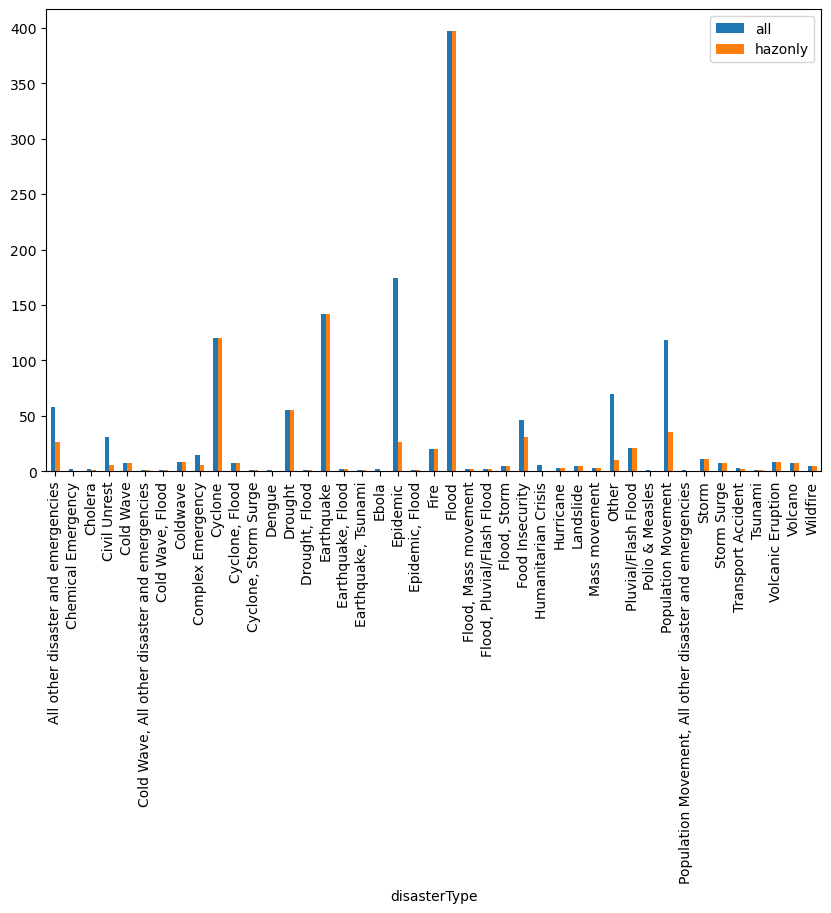

In [41]:
joined_df.plot(kind='bar', figsize=(10, 6))

## Select subsections containing natural hazard info

In [ ]:
for report in filtered_reports_hazonly[:]:
    report['nathaz_text'] = select_hazard_description(report['text_processed'])

## Save data

In [ ]:
file_path = DATA_FOLDER + '/all_ifrc_reports_info_processed.json' #not sure if this is the correct file
with open(file_path, 'w') as f:
    json.dump(filtered_reports, f, indent=4)